# Experiment 2 — Geometry: Phase 3, Evaluation

Reads the Phase 2 results and produces every metric in §5.3, plus the guards we
added after the pilot runs showed which can be reported naively and which cannot.

**Input** `results.jsonl` or `result.json` (either format).

---

## What §5.3 asks for

| Metric | Cell |
|---|---|
| End-to-end correctness | 9 |
| Per-step correctness | 6, 10 |
| Error Amplification Factor | 11 |
| Augmentation Gain | 7 |
| Object-Handle Recovery Gain | 7 |

## Table 4, the prediction being tested

| Pipeline type | Raw | Handle only | Handle + summary |
|---|---|---|---|
| Pass-through | Medium | **High** | High |
| Property-conditioned | Low | Low–Medium | **High** |
| Multi-object | **Very low** | Low–Medium | **High** |

The prediction is not just that summaries help. It is that the rows respond to
**different** fixes: pass-through to the handle, because the object no longer has
to be carried; the gated categories to the summary, because that is what exposes
the property. That crossing separates state preservation from decision exposure,
which is the thing the literature currently conflates.

## Seven guards, each from something that went wrong

**1. Deduplicate first.** A rate-limited run that restarts re-executes arms that
had already finished, so the same (pipeline, condition, mode) can appear twice.
The later row supersedes the earlier one.

**2. Never pool per-step accuracy across modes.** Cascading aborts, so a run that
ends at step 1 contributes one scored step and later indices are a survivor
subset. In an early pilot this made cascading score 0.647 against oracle's 0.522
when it should be lower.

**3. Never pool AG or OHG across categories.** Pass-through runs near ceiling and
has no headroom, so a pooled gain is dominated by a category that cannot move.

**4. Report the survival curve.** Under a fatal-abort policy it is the honest
picture of compounding and the denominator that makes per-step accuracy
interpretable.

**5. Suppress EAF when it is uninformative.** Cells with n=1 produced values of
6.39 and 0.0 in a pilot. Suppressed below n=20 and when the independence
prediction saturates above 0.99.

**6. Report accuracy against chance.** A threshold step is a two-way branch
(chance 0.500); a selection step picks one of three objects (chance 0.333).
Without this, 0.31 under raw looks like partial competence when it is barely
above chance.

**7. `parse_error` is its own failure cause.** Never folded into `wrong_tool`: a
formatting failure is a different claim from a reconstruction failure. Note the
`pd.notna` guards — a missing value is NaN, and `bool(nan)` is True, which in an
earlier version classified every failure as a parse error.

## Also reported

Auxiliary-tool usage, which is new. `get_property` and `get_object` are the only
route to a property under `handle`, so their usage is the price of a bare handle,
paid in round trips rather than in accuracy.

## [CELL 1] Setup

In [1]:
!pip install pandas numpy matplotlib --quiet

import json, math, sys
from collections import Counter, defaultdict
from pathlib import Path
import numpy as np, pandas as pd

pd.set_option("display.width", 220); pd.set_option("display.max_rows", 250)
BASE = Path.cwd()
print("pandas", pd.__version__)

pandas 2.3.3


## [CELL 2] Load the results

Accepts `results.jsonl`, a JSON array, or the `{"results": [...]}` export.

In [ ]:
IN_COLAB = "google.colab" in sys.modules

def _find(*names):
    for n in names:
        for p in [BASE/n, BASE/"data"/n, Path("/content")/n]:
            if p.exists(): return p
    if IN_COLAB:
        from google.colab import files
        print("Upload your Phase 2 results file:")
        return Path(next(iter(files.upload())))
    raise FileNotFoundError(names)

RESULTS = "results/gpt-4.1-mini/results.json"   # relative to this notebook
print("results:", RESULTS)

results: /Users/mn/Downloads/files (1) (1)/geometry_v8_notebooks/results/deepseek-v4-flash/results.json


## [CELL 3] Metric definitions

Read the docstrings before changing anything: each encodes a guard.

In [3]:
import json, math
from collections import Counter, defaultdict
import numpy as np, pandas as pd

CONDITIONS = ["raw", "augmented", "handle", "handle_sum"]
CATEGORIES = ["pass_through", "property_conditioned", "multi_object"]
MODES = ["cascading", "oracle"]
CLABEL = {"raw":"raw","augmented":"augmented","handle":"handle","handle_sum":"handle+sum"}
CATLABEL = {"pass_through":"pass-through","property_conditioned":"property-cond.",
            "multi_object":"multi-object"}
EXP1_P = {"area":0.051, "perimeter":0.208, "bbox":0.944, "vertex_count":0.980}
MIN_N_EAF, MAX_PRED_FAIL = 20, 0.99


# ------------------------------------------------------------------ loading
def _records(path):
    """Accepts results.jsonl, a JSON array, or the {"results": [...]} export."""
    with open(path) as fh:
        head = fh.read(2048).lstrip(); fh.seek(0)
        if head.startswith("[") or head.startswith("{"):
            payload = json.load(fh)
            if isinstance(payload, dict):
                recs = payload.get("results") or payload.get("runs") or []
            else:
                recs = payload
            print(f"  format: JSON ({len(recs):,} records)")
            return recs
        recs = [json.loads(l) for l in fh if l.strip()]
        print(f"  format: JSON Lines ({len(recs):,} records)")
        return recs


def deduplicate(recs):
    """Keep the LATEST arm per (pipeline_id, condition, mode).

    A rate-limited run that is restarted re-executes arms that were already
    finished, so the same arm can appear more than once. Later rows supersede
    earlier ones; taking the last occurrence is what the runner's own append
    order already implies.
    """
    seen, out = {}, []
    for i, r in enumerate(recs):
        seen[(r["pipeline_id"], r["condition"], r["mode"])] = i
    keep = set(seen.values())
    dropped = len(recs) - len(keep)
    for i, r in enumerate(recs):
        if i in keep: out.append(r)
    return out, dropped


def load(path):
    recs = _records(path)
    recs, dropped = deduplicate(recs)
    if dropped:
        print(f"  deduplicated: dropped {dropped:,} superseded arm(s)")
    runs, steps = [], []
    for r in recs:
        runs.append({k: r.get(k) for k in (
            "pipeline_id","category","gate_property","depth","tier","shape_type",
            "condition","mode","model","n_steps","steps_scored","steps_correct",
            "aux_calls_total","calls_correct","end_to_end_correct",
            "final_state_matches_reference","aborted","backend_error",
            "first_incorrect_step","ends_terminal")})
        for s in r.get("steps", []):
            steps.append({
                "pipeline_id": r["pipeline_id"], "category": r["category"],
                "gate_property": r["gate_property"], "depth": r["depth"],
                "tier": r["tier"], "condition": r["condition"], "mode": r["mode"],
                "step_index": s.get("index"), "kind": s.get("kind"),
                "mechanism": s.get("mechanism"), "margin": s.get("decision_margin"),
                "is_noop": bool(s.get("is_noop")), "scored": bool(s.get("scored")),
                "correct": s.get("correct"), "call_correct": s.get("call_correct"),
                "tool_ok": s.get("tool_ok"), "args_ok": s.get("args_ok"),
                "objects_ok": s.get("objects_ok"),
                "object_failure": s.get("object_failure"),
                "parse_error": s.get("parse_error"),
                "execution_error": s.get("execution_error"),
                "aux_calls": s.get("aux_calls", 0),
                "model_tool": s.get("model_tool"),
                "input_tokens": s.get("input_tokens"),
                "output_tokens": s.get("output_tokens"),
                "latency_ms": s.get("latency_ms")})
    return pd.DataFrame(runs), pd.DataFrame(steps)


# ------------------------------------------------------- bootstrap, clustered
def boot_ci(values, clusters=None, n=4000, seed=0, alpha=0.05):
    v = np.asarray(values, float)
    if v.size == 0: return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    if clusters is None:
        means = v[rng.integers(0, v.size, (n, v.size))].mean(1)
    else:
        g = np.asarray(clusters); uniq = np.unique(g)
        buckets = [v[g == u] for u in uniq]
        means = np.empty(n)
        for i in range(n):
            pick = rng.integers(0, len(buckets), len(buckets))
            means[i] = np.concatenate([buckets[j] for j in pick]).mean()
    return float(v.mean()), float(np.percentile(means, 100*alpha/2)), \
           float(np.percentile(means, 100*(1-alpha/2)))


# ---------------------------------------------------------------- coverage
def coverage(runs, steps):
    problems = []
    print(f"runs {len(runs):,} | steps {len(steps):,} | pipelines "
          f"{runs.pipeline_id.nunique():,} | model {runs.model.iloc[0]}")
    exp = runs.pipeline_id.nunique() * len(CONDITIONS) * len(MODES)
    print(f"\nexpected arms {exp:,}   present {len(runs):,}   missing {exp-len(runs):,}")
    if len(runs) != exp:
        problems.append(f"{exp-len(runs)} arms missing")
    piv = runs.pivot_table(index="condition", columns="mode",
                           values="pipeline_id", aggfunc="count")
    print("\nCONDITION x MODE"); print(piv.to_string())
    if piv.values.std() > 0.02*piv.values.mean():
        problems.append("condition x mode cells unbalanced")
    print("\nCATEGORY"); print(runs.groupby("category").pipeline_id.nunique().to_string())
    print("\nGATE");     print(runs.groupby("gate_property").pipeline_id.nunique().to_string())
    print("\n" + ("coverage OK" if not problems else "PROBLEMS: " + "; ".join(problems)))
    return problems


# ----------------------------------------------------------------- metrics
def table4(steps, mode="oracle"):
    """Section 5.3 Table 4: per-step accuracy, category x condition.

    Reported under oracle. Cascading per-step accuracy is survivorship-biased,
    because an aborted run contributes only the steps it reached.
    """
    d = steps[(steps.scored == True) & (steps["mode"] == mode)]
    rows = []
    for cat in CATEGORIES:
        s = d[d.category == cat]
        if not len(s): continue
        row = {"category": cat, "n": len(s)}
        for c in CONDITIONS:
            g = s[s.condition == c]
            m, lo, hi = boot_ci(g.correct.astype(float), g.pipeline_id)
            row[c] = m; row[c+"_lo"] = lo; row[c+"_hi"] = hi
        rows.append(row)
    return pd.DataFrame(rows)


def gains(steps, mode="oracle"):
    """AG and OHG, ALWAYS per category.

    Pooling is invalid: pass-through runs near ceiling and cannot move, so a
    pooled gain is dominated by a category with no headroom.
    """
    t = table4(steps, mode)
    out = t[["category","n","raw","augmented","handle","handle_sum"]].copy()
    out["AG"] = out.augmented - out.raw
    out["OHG"] = out.handle - out.raw
    out["OHG_sum"] = out.handle_sum - out.raw
    return out


def gains_by_gate(steps, mode="oracle"):
    """AG against the Experiment 1 difficulty of the gated property."""
    d = steps[(steps.scored == True) & (steps["mode"] == mode)
              & (steps.category != "pass_through")]
    rows = []
    for g in sorted(d.gate_property.dropna().unique()):
        s = d[d.gate_property == g]
        a = {c: s[s.condition == c].correct.mean() for c in CONDITIONS}
        rows.append(dict(gate=g, p_exp1=EXP1_P.get(g), n=len(s), raw=a["raw"],
                         AG=a["augmented"]-a["raw"], OHG=a["handle"]-a["raw"],
                         OHG_sum=a["handle_sum"]-a["raw"]))
    return pd.DataFrame(rows).sort_values("p_exp1")


def per_step_by_index(steps, category=None):
    """Never pooled across modes: cascading aborts, so later indices are a
    survivor subset."""
    d = steps[steps.scored == True]
    if category: d = d[d.category == category]
    out = []
    for (c, m, k), g in d.groupby(["condition","mode","step_index"]):
        a, lo, hi = boot_ci(g.correct.astype(float), g.pipeline_id)
        out.append(dict(condition=c, mode=m, step_index=k, acc=a, lo=lo, hi=hi,
                        n=len(g), thin=len(g) < 20))
    return pd.DataFrame(out).sort_values(["condition","mode","step_index"])


def survival(runs, steps):
    c = steps[steps["mode"] == "cascading"]
    tot = runs[runs["mode"] == "cascading"].groupby(
        ["condition","category"]).pipeline_id.nunique().rename("n_total")
    reach = c.groupby(["condition","category","step_index"]).pipeline_id.nunique().rename("n_reached")
    out = reach.reset_index().merge(tot.reset_index(), on=["condition","category"])
    out["survival"] = out.n_reached / out.n_total
    return out


def end_to_end(runs):
    """Both definitions. e2e_geometry is section 5.3's 'does the final output
    match the ground-truth', which can hold when an early error is absorbed."""
    out = []
    for (c, m, cat), g in runs.groupby(["condition","mode","category"]):
        calls = g.end_to_end_correct.astype(float)
        geom = g.final_state_matches_reference.dropna().astype(float)
        mc, lc, hc = boot_ci(calls)
        mg = float(geom.mean()) if len(geom) else np.nan
        out.append(dict(condition=c, mode=m, category=cat, e2e_calls=mc,
                        lo=lc, hi=hc, e2e_geometry=mg, n=len(g)))
    return pd.DataFrame(out)


def eaf(runs, steps):
    """EAF(k) = observed cascading failure / failure predicted under independence.

    p comes from ORACLE per-step accuracy, which is the clean per-step burden.
    Suppressed when n is small or the independence prediction saturates:
    dividing a near-one by a near-one carries no information.
    """
    ps = steps[(steps.scored == True) & (steps["mode"] == "oracle")]
    p_by = ps.groupby(["condition","category","step_index"]).correct.mean()
    obs = runs[runs["mode"] == "cascading"].groupby(
        ["condition","category","depth"]).end_to_end_correct.agg(["mean","size"])
    out = []
    for (c, cat, dep), (acc, n) in obs.iterrows():
        try:
            pk = [p_by.loc[(c, cat, k)] for k in range(int(dep))]
        except KeyError:
            continue
        pred_fail = 1 - float(np.prod(pk)); obs_fail = 1 - acc
        ok = (n >= MIN_N_EAF) and (1e-6 < pred_fail < MAX_PRED_FAIL)
        out.append(dict(condition=c, category=cat, depth=int(dep), n=int(n),
                        pred_fail=pred_fail, obs_fail=obs_fail,
                        EAF=(obs_fail/pred_fail) if ok else np.nan,
                        suppressed="" if ok else
                                   (f"n<{MIN_N_EAF}" if n < MIN_N_EAF else "prediction saturated")))
    return pd.DataFrame(out)


def aux_usage(steps):
    """Did the model discover get_property / get_object?

    Under `handle` no property can be inferred from an identifier, so an
    auxiliary read is the only route. Usage is the price of a bare handle, paid
    in round trips rather than in accuracy.
    """
    d = steps[steps.scored == True]
    return (d.groupby(["condition","category"])
              .agg(aux_per_step=("aux_calls","mean"),
                   pct_steps_with_aux=("aux_calls", lambda x: 100*(x>0).mean()),
                   acc=("correct","mean"), n=("correct","size"))
              .round(3).reset_index())


def aborts(runs):
    c = runs[runs["mode"] == "cascading"].copy()
    c["flag"] = c.aborted.notna()
    c["cause"] = c.aborted.fillna("").astype(str).str.split(":").str[0].replace("", None)
    rate = (c.pivot_table(index="condition", columns="category",
                          values="flag", aggfunc="mean")*100).round(1)
    cause = pd.crosstab(c[c.flag].cause, c[c.flag].condition)
    return rate, cause


def failure_attribution(steps):
    """parse_error is its own cause and never folded into wrong_tool: a
    formatting failure is a different claim from a reconstruction failure.

    pd.notna guards matter - a missing value is NaN and bool(nan) is True.
    """
    d = steps[(steps.scored == True) & (steps.correct == False)].copy()
    if not len(d): return pd.DataFrame()
    def lab(r):
        if pd.notna(r.parse_error) and str(r.parse_error).strip(): return "parse_error"
        if pd.notna(r.execution_error) and str(r.execution_error).strip(): return "execution_error"
        if r.tool_ok == False: return "wrong_tool"
        if r.objects_ok == False: return "wrong_object"
        if r.args_ok == False: return "wrong_args"
        return "other"
    d["cause"] = d.apply(lab, axis=1)
    return pd.crosstab(d.cause, d.condition)


def chance_baseline(steps):
    """Threshold steps enumerate two branches (chance 0.5); selection steps pick
    one of three objects (chance 1/3). Without this, 0.31 under raw looks like
    partial competence when it is barely above chance."""
    d = steps[steps.scored == True].copy()
    d["chance"] = np.where(d.kind == "select", 1/3,
                   np.where(d.kind == "gated", 0.5, 1.0))
    return (d.groupby(["condition","category"])
              .agg(acc=("correct","mean"), chance=("chance","mean"), n=("correct","size"))
              .assign(lift=lambda x: x.acc - x.chance).round(3).reset_index())


def token_cost(steps):
    return (steps.groupby("condition")
              .agg(input_tokens=("input_tokens","sum"),
                   in_per_call=("input_tokens","mean"),
                   out_per_call=("output_tokens","mean"),
                   latency_ms=("latency_ms","median"), calls=("correct","size"))
              .round(1).reset_index())

## [CELL 4] Load and deduplicate

Guard 1.

In [4]:
runs, steps = load(str(RESULTS))
print()
problems = coverage(runs, steps)

  format: JSON (7,392 records)

runs 7,392 | steps 33,552 | pipelines 924 | model deepseek-v4-flash

expected arms 7,392   present 7,392   missing 0

CONDITION x MODE
mode        cascading  oracle
condition                    
augmented         924     924
handle            924     924
handle_sum        924     924
raw               924     924

CATEGORY
category
multi_object            441
pass_through            168
property_conditioned    315

GATE
gate_property
area                    126
aspect_ratio            168
convex                   42
edge_length_variance    126
perimeter               168
vertex_count             63
width                    63

coverage OK


## [CELL 5] Table 4 as measured

The headline. Reported under oracle, because cascading per-step accuracy is
survivorship-biased.

In [5]:
t4 = table4(steps)
print(t4.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

raw = {r.category: r.raw for r in t4.itertuples()}
order_ok = (raw.get("pass_through", 0) > raw.get("property_conditioned", 0)
            > raw.get("multi_object", 0))
print(f"\nrequired ordering under raw: pass_through > property_conditioned > multi_object")
print(f"observed: {raw.get('pass_through'):.3f} > {raw.get('property_conditioned'):.3f} "
      f"> {raw.get('multi_object'):.3f}   -> {'HOLDS' if order_ok else 'VIOLATED'}")

PREDICTED_RAW = {"pass_through": 0.800, "property_conditioned": 0.705,
                 "multi_object": 0.488}   # from Phase 1, before the run
print("\npredicted in Phase 1:", PREDICTED_RAW)

            category    n   raw  raw_lo  raw_hi  augmented  augmented_lo  augmented_hi  handle  handle_lo  handle_hi  handle_sum  handle_sum_lo  handle_sum_hi
        pass_through 3072 1.000   1.000   1.000      1.000         1.000         1.000   1.000      1.000      1.000       1.000          1.000          1.000
property_conditioned 5760 0.559   0.510   0.610      1.000         1.000         1.000   0.812      0.774      0.847       1.000          1.000          1.000
        multi_object 8064 0.451   0.413   0.491      0.990         0.982         0.995   0.582      0.537      0.626       0.996          0.992          0.999

required ordering under raw: pass_through > property_conditioned > multi_object
observed: 1.000 > 0.559 > 0.451   -> HOLDS

predicted in Phase 1: {'pass_through': 0.8, 'property_conditioned': 0.705, 'multi_object': 0.488}


## [CELL 6] Per-step accuracy by index

Guard 2. Never pooled across modes; `thin` marks cells below n=20.

In [6]:
for cat in CATEGORIES:
    t = per_step_by_index(steps, cat)
    if not len(t): continue
    print("="*78); print(cat.upper()); print("="*78)
    print(t.to_string(index=False, float_format=lambda x: f"{x:.3f}")); print()

PASS_THROUGH
 condition      mode  step_index   acc    lo    hi   n  thin
 augmented cascading           0 1.000 1.000 1.000 168 False
 augmented cascading           1 1.000 1.000 1.000 144 False
 augmented cascading           2 1.000 1.000 1.000 120 False
 augmented cascading           3 1.000 1.000 1.000  96 False
 augmented cascading           4 1.000 1.000 1.000  72 False
 augmented cascading           5 1.000 1.000 1.000  48 False
 augmented cascading           6 1.000 1.000 1.000  48 False
 augmented cascading           7 1.000 1.000 1.000  24 False
 augmented cascading           8 1.000 1.000 1.000  24 False
 augmented cascading           9 1.000 1.000 1.000  24 False
 augmented    oracle           0 1.000 1.000 1.000 168 False
 augmented    oracle           1 1.000 1.000 1.000 144 False
 augmented    oracle           2 1.000 1.000 1.000 120 False
 augmented    oracle           3 1.000 1.000 1.000  96 False
 augmented    oracle           4 1.000 1.000 1.000  72 False
 augmented 

## [CELL 7] AG and OHG, per category

Guard 3.

In [7]:
g = gains(steps)
print(g.to_string(index=False, float_format=lambda x: f"{x:+.3f}"))
print("\nby gate property, ordered by Experiment 1 difficulty:")
gg = gains_by_gate(steps)
print(gg.to_string(index=False, float_format=lambda x: f"{x:+.3f}"))

            category    n    raw  augmented  handle  handle_sum     AG    OHG  OHG_sum
        pass_through 3072 +1.000     +1.000  +1.000      +1.000 +0.000 +0.000   +0.000
property_conditioned 5760 +0.559     +1.000  +0.812      +1.000 +0.441 +0.253   +0.441
        multi_object 8064 +0.451     +0.990  +0.582      +0.996 +0.538 +0.130   +0.544

by gate property, ordered by Experiment 1 difficulty:
                gate  p_exp1    n    raw     AG    OHG  OHG_sum
                area  +0.051 2304 +0.620 +0.372 -0.111   +0.375
           perimeter  +0.208 3072 +0.482 +0.517 +0.145   +0.517
        vertex_count  +0.980 1152 +0.774 +0.226 +0.097   +0.226
        aspect_ratio     NaN 3072 +0.243 +0.750 +0.520   +0.755
              convex     NaN  768 +0.766 +0.234 -0.031   +0.234
edge_length_variance     NaN 2304 +0.464 +0.523 +0.095   +0.530
               width     NaN 1152 +0.569 +0.424 +0.361   +0.431


## [CELL 8] Auxiliary tool use

Under `handle` no property can be inferred from an identifier, so a read is the
only route. Usage is the cost of a bare handle.

In [8]:
ax_df = aux_usage(steps)
print(ax_df.to_string(index=False))
print("\nper condition:")
for c in CONDITIONS:
    s = steps[(steps.scored == True) & (steps.condition == c)]
    print(f"  {c:12s} aux/step {s.aux_calls.mean():.3f}   "
          f"steps with a read {100*(s.aux_calls>0).mean():5.1f}%")

 condition             category  aux_per_step  pct_steps_with_aux   acc    n
 augmented         multi_object         0.000               0.000 0.991 4032
 augmented         pass_through         0.000               0.000 1.000 1536
 augmented property_conditioned         0.000               0.000 1.000 2880
    handle         multi_object         1.355              62.659 0.586 4009
    handle         pass_through         0.000               0.000 1.000 1536
    handle property_conditioned         0.950              94.958 0.808 2876
handle_sum         multi_object         0.000               0.000 0.995 4032
handle_sum         pass_through         0.000               0.000 1.000 1536
handle_sum property_conditioned         0.000               0.000 1.000 2880
       raw         multi_object         0.000               0.000 0.474 3887
       raw         pass_through         0.000               0.000 1.000 1536
       raw property_conditioned         0.000               0.000 0.610 2812

## [CELL 9] End-to-end, both definitions

`e2e_calls` is every call correct. `e2e_geometry` is §5.3's *does the final
output match the ground-truth*, which can hold when an early error is absorbed.

In [9]:
e2e = end_to_end(runs)
print(e2e[e2e["mode"]=="oracle"].to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print()
print(e2e[e2e["mode"]=="cascading"].to_string(index=False, float_format=lambda x: f"{x:.3f}"))

 condition   mode             category  e2e_calls    lo    hi  e2e_geometry   n
 augmented oracle         multi_object      0.964 0.946 0.980           NaN 441
 augmented oracle         pass_through      1.000 1.000 1.000           NaN 168
 augmented oracle property_conditioned      1.000 1.000 1.000           NaN 315
    handle oracle         multi_object      0.379 0.333 0.424           NaN 441
    handle oracle         pass_through      1.000 1.000 1.000           NaN 168
    handle oracle property_conditioned      0.648 0.594 0.702           NaN 315
handle_sum oracle         multi_object      0.984 0.971 0.995           NaN 441
handle_sum oracle         pass_through      1.000 1.000 1.000           NaN 168
handle_sum oracle property_conditioned      1.000 1.000 1.000           NaN 315
       raw oracle         multi_object      0.190 0.154 0.227           NaN 441
       raw oracle         pass_through      1.000 1.000 1.000           NaN 168
       raw oracle property_conditioned  

## [CELL 10] Survival and aborts

Guards 4 and 7.

In [10]:
sv = survival(runs, steps)
print("SURVIVAL UNDER CASCADING")
print(sv.pivot_table(index=["category","step_index"], columns="condition",
                     values="survival").round(3).to_string())
rate, cause = aborts(runs)
print("\nABORT RATE %  (condition x category)"); print(rate.to_string())
print("\nCAUSES"); print(cause.to_string() if len(cause) else "(none)")
fa = failure_attribution(steps)
print("\nFAILURE ATTRIBUTION (mutually exclusive, priority order)")
print(fa.to_string() if len(fa) else "(no failures)")
if len(fa):
    tot = fa.values.sum()
    pe = fa.loc["parse_error"].sum() if "parse_error" in fa.index else 0
    print(f"\nparse-related share: {pe}/{tot} = {100*pe/tot:.0f}%")
    if pe/tot > 0.20:
        print("  -> a substantial part of the failure rate is OUTPUT FORMAT, not")
        print("     property reconstruction. Report the two separately.")

SURVIVAL UNDER CASCADING
condition                        augmented  handle  handle_sum    raw
category             step_index                                      
multi_object         0               1.000   1.000       1.000  1.000
                     1               0.857   0.846       0.857  0.823
                     2               0.714   0.701       0.714  0.649
                     3               0.571   0.562       0.571  0.515
                     4               0.429   0.422       0.429  0.379
                     5               0.286   0.283       0.286  0.256
                     6               0.286   0.283       0.286  0.256
                     7               0.143   0.141       0.143  0.122
                     8               0.143   0.141       0.143  0.122
                     9               0.143   0.141       0.143  0.120
pass_through         0               1.000   1.000       1.000  1.000
                     1               0.857   0.857       0.857  0

## [CELL 11] EAF and chance baselines

Guards 5 and 6.

In [11]:
E = eaf(runs, steps)
ok = E[E.EAF.notna()]
print(f"EAF: {len(ok)} of {len(E)} cells reportable; EAF > 1 in {(ok.EAF>1).sum()}")
print(ok.sort_values(["category","condition","depth"]).to_string(index=False,
      float_format=lambda x: f"{x:.3f}"))
print("\nsuppressed cells:", dict(Counter(E[E.EAF.isna()].suppressed)))
cb = chance_baseline(steps)
print("\nACCURACY VS CHANCE")
print(cb.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
tc = token_cost(steps)
print("\nTOKEN COST"); print(tc.to_string(index=False))

EAF: 38 of 84 cells reportable; EAF > 1 in 6
 condition             category  depth  n  pred_fail  obs_fail   EAF suppressed
 augmented         multi_object      1 63      0.025     0.016 0.636           
 augmented         multi_object      2 63      0.030     0.048 1.582           
 augmented         multi_object      3 63      0.039     0.048 1.210           
 augmented         multi_object      4 63      0.055     0.000 0.000           
 augmented         multi_object      5 63      0.060     0.016 0.266           
 augmented         multi_object      7 63      0.060     0.032 0.533           
 augmented         multi_object     10 63      0.060     0.016 0.266           
    handle         multi_object      1 63      0.410     0.333 0.812           
    handle         multi_object      2 63      0.679     0.603 0.889           
    handle         multi_object      3 63      0.815     0.651 0.798           
    handle         multi_object      4 63      0.893     0.524 0.587       

## [CELL 12] Figure definitions

One hue per condition throughout, so the reader learns the colour once.

In [12]:
!pip install matplotlib --quiet

import numpy as np, pandas as pd
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt

CC = {"raw":"#B3261E","augmented":"#1F6FB2","handle":"#8A6D3B","handle_sum":"#157347"}
plt.rcParams.update({"figure.dpi":130,"savefig.dpi":200,"font.size":9,
                     "axes.spines.top":False,"axes.spines.right":False,
                     "axes.grid":True,"grid.alpha":0.25,"grid.linewidth":0.6})

def _save(fig, path):
    fig.tight_layout(); fig.savefig(path, bbox_inches="tight"); plt.close(fig)
    print(f"  wrote {path}")


def fig_table4(t4, out="fig1_table4.png"):
    """Section 5.3 Table 4 as measured. The prediction is that rows respond to
    DIFFERENT fixes: pass-through to the handle, the gated categories to the
    summary. That crossing is what separates state preservation from decision
    exposure."""
    t4 = t4.set_index("category").reindex(CATEGORIES).dropna(how="all").reset_index()
    fig, ax = plt.subplots(figsize=(8.0, 3.8))
    x = np.arange(len(t4)); w = 0.2
    for i, c in enumerate(CONDITIONS):
        v = t4[c].values
        err = np.vstack([v - t4[c+"_lo"].values, t4[c+"_hi"].values - v])
        b = ax.bar(x + (i-1.5)*w, v, w, label=CLABEL[c], color=CC[c],
                   edgecolor="white", lw=0.6, yerr=err, capsize=2,
                   error_kw=dict(lw=0.8, ecolor="#444"))
        for rect, val in zip(b, v):
            ax.annotate(f"{val:.2f}", (rect.get_x()+rect.get_width()/2, val),
                        textcoords="offset points", xytext=(0,9),
                        ha="center", fontsize=7.5)
    ax.set_xticks(x); ax.set_xticklabels([CATLABEL[c] for c in t4.category])
    ax.set_ylabel("per-step accuracy (oracle)"); ax.set_ylim(0, 1.12)
    ax.set_title("Table 4 as measured  (bars: 95% bootstrap CI, clustered on pipeline)",
                 loc="left", fontsize=10)
    ax.legend(frameon=False, fontsize=8, ncol=4, loc="upper center",
              bbox_to_anchor=(0.5, 1.02))
    _save(fig, out)


def fig_ordering(t4, predicted=None, out="fig2_ordering.png"):
    """The specification requires pass_through > property_conditioned >
    multi_object under raw. Phase 1 predicted the values before the run."""
    t4 = t4.set_index("category").reindex(CATEGORIES).dropna(how="all")
    fig, ax = plt.subplots(figsize=(6.6, 3.4))
    x = np.arange(len(t4))
    obs = t4["raw"].values
    ax.plot(x, obs, "o-", color="#B3261E", lw=2, ms=9, label="observed (raw)")
    for i, v in enumerate(obs):
        ax.annotate(f"{v:.3f}", (i, v), textcoords="offset points",
                    xytext=(0, 12), ha="center", fontsize=9)
    if predicted:
        pv = [predicted.get(c) for c in t4.index]
        ax.plot(x, pv, "s--", color="#666", lw=1.4, ms=7, label="predicted in Phase 1")
        for i, v in enumerate(pv):
            if v is not None:
                ax.annotate(f"{v:.3f}", (i, v), textcoords="offset points",
                            xytext=(0, -18), ha="center", fontsize=8, color="#666")
    ax.set_xticks(x); ax.set_xticklabels([CATLABEL[c] for c in t4.index])
    ax.set_ylabel("per-step accuracy under raw"); ax.set_ylim(0, 1.05)
    ok = obs[0] > obs[1] > obs[2]
    ax.set_title(f"Required ordering pass-through > property-cond. > multi-object"
                 f"   [{'HOLDS' if ok else 'VIOLATED'}]", loc="left", fontsize=10)
    ax.legend(frameon=False, fontsize=8)
    _save(fig, out)


def fig_gains(g, out="fig3_gains.png"):
    """Never pooled across categories: pass-through has no headroom, so a pooled
    gain is dominated by a category that cannot move."""
    g = g.set_index("category").reindex(CATEGORIES).dropna(how="all").reset_index()
    fig, ax = plt.subplots(figsize=(7.4, 3.6))
    x = np.arange(len(g)); w = 0.26
    for i, (k, lab, col) in enumerate([("AG","AG  (augmented − raw)","#1F6FB2"),
                                       ("OHG","OHG  (handle − raw)","#8A6D3B"),
                                       ("OHG_sum","OHG+sum  (handle+sum − raw)","#157347")]):
        v = g[k].values
        b = ax.bar(x + (i-1)*w, v, w, label=lab, color=col, edgecolor="white", lw=0.6)
        for rect, val in zip(b, v):
            ax.annotate(f"{val:+.2f}", (rect.get_x()+rect.get_width()/2,
                        val + (0.012 if val >= 0 else -0.032)), ha="center", fontsize=7.5)
    ax.axhline(0, color="#333", lw=0.9)
    ax.set_xticks(x); ax.set_xticklabels([CATLABEL[c] for c in g.category])
    ax.set_ylabel("change in per-step accuracy")
    ax.set_title("Augmentation and object-handle gain, by category (oracle)",
                 loc="left", fontsize=10)
    ax.legend(frameon=False, fontsize=8, loc="upper left")
    _save(fig, out)


def fig_gate_gradient(gg, out="fig4_gate_gradient.png"):
    """Does the summary help more where the property is harder to recover?"""
    gg = gg.dropna(subset=["p_exp1"]).sort_values("p_exp1")
    fig, ax = plt.subplots(figsize=(6.6, 3.6))
    ax.plot(gg.p_exp1, gg.AG, "o-", color="#1F6FB2", lw=1.8, ms=8, label="AG")
    ax.plot(gg.p_exp1, gg.OHG_sum, "s--", color="#157347", lw=1.6, ms=7, label="OHG+sum")
    offs = [(0,13),(0,13),(30,8),(30,-18)]
    for (_, r), off in zip(gg.iterrows(), offs):
        ax.annotate(f"{r.gate}\nn={int(r.n):,}", (r.p_exp1, r.AG),
                    textcoords="offset points", xytext=off, ha="center", fontsize=7.5)
    ax.axhline(0, color="#333", lw=0.9); ax.set_xscale("log")
    ax.set_xlim(0.03, 2.6)
    ax.set_xlabel("Experiment 1 recovery accuracy of the gated property (log scale)")
    ax.set_ylabel("gain over raw")
    ax.set_title("Does the summary help most where the property is hardest?",
                 loc="left", fontsize=10)
    ax.legend(frameon=False, fontsize=8)
    _save(fig, out)


def fig_survival(sv, out="fig5_survival.png"):
    """Under a fatal-abort policy this is the compounding picture, and it is the
    denominator that makes per-step accuracy interpretable."""
    cats = [c for c in CATEGORIES if c in set(sv.category)]
    fig, axes = plt.subplots(1, len(cats), figsize=(3.7*len(cats), 3.2), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, cat in zip(axes, cats):
        s = sv[sv.category == cat]
        for c in CONDITIONS:
            v = s[s.condition == c].sort_values("step_index")
            if len(v):
                ax.plot(v.step_index+1, v.survival, "o-", ms=4, lw=1.6,
                        color=CC[c], label=CLABEL[c])
        ax.set_title(CATLABEL[cat], fontsize=9.5); ax.set_xlabel("step"); ax.set_ylim(0, 1.03)
    axes[0].set_ylabel("fraction still executing")
    axes[-1].legend(frameon=False, fontsize=8)
    fig.suptitle("Survival under cascading propagation", x=0.01, ha="left", fontsize=10)
    _save(fig, out)


def fig_perstep(ps, category, out=None):
    """Oracle and cascading answer different questions and are never pooled.
    Cascading rising while its denominator collapses is survivorship."""
    out = out or f"fig6_perstep_{category}.png"
    fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.4), sharey=True)
    for ax, mode in zip(axes, ["oracle","cascading"]):
        s = ps[ps["mode"] == mode]
        for c in CONDITIONS:
            v = s[s.condition == c].sort_values("step_index")
            if len(v):
                ax.plot(v.step_index+1, v.acc, "o-", ms=4, lw=1.6, color=CC[c],
                        label=CLABEL[c])
                ax.fill_between(v.step_index+1, v.lo, v.hi, color=CC[c], alpha=0.12)
        ax.set_title(mode, fontsize=9.5); ax.set_xlabel("step index"); ax.set_ylim(0, 1.05)
    axes[0].set_ylabel("per-step accuracy")
    axes[1].legend(frameon=False, fontsize=8, loc="lower left")
    fig.suptitle(f"Per-step accuracy — {CATLABEL.get(category, category)}",
                 x=0.01, ha="left", fontsize=10)
    _save(fig, out)


def fig_aux(ax_df, out="fig7_aux.png"):
    """get_property and get_object are the only route to a property under
    `handle`. Usage is the cost of a bare handle, paid in round trips."""
    p = ax_df.pivot_table(index="condition", columns="category",
                          values="aux_per_step").reindex(CONDITIONS)
    fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.2))
    p.plot(kind="bar", ax=axes[0], width=0.75, edgecolor="white", lw=0.6)
    axes[0].set_ylabel("auxiliary calls per step"); axes[0].set_xlabel("")
    axes[0].set_xticklabels([CLABEL[c] for c in p.index], rotation=0, fontsize=8.5)
    axes[0].legend([CATLABEL.get(c, c) for c in p.columns], frameon=False, fontsize=7.5)
    axes[0].set_title("auxiliary read usage", fontsize=9.5)
    q = ax_df.pivot_table(index="condition", columns="category",
                          values="acc").reindex(CONDITIONS)
    q.plot(kind="bar", ax=axes[1], width=0.75, edgecolor="white", lw=0.6, legend=False)
    axes[1].set_ylabel("per-step accuracy"); axes[1].set_xlabel("")
    axes[1].set_xticklabels([CLABEL[c] for c in q.index], rotation=0, fontsize=8.5)
    axes[1].set_title("accuracy, same cells", fontsize=9.5)
    fig.suptitle("Do the read tools buy accuracy, and at what cost?",
                 x=0.01, ha="left", fontsize=10)
    _save(fig, out)


def fig_chance(cb, out="fig8_chance.png"):
    """Accuracy against what a model that cannot see the property would score by
    choosing at random: 0.5 for a two-way branch, 1/3 for a three-way selection."""
    d = cb[cb.category != "pass_through"]
    cats = sorted(set(d.category))
    fig, ax = plt.subplots(figsize=(7.4, 3.4))
    k, labels = 0, []
    for cat in cats:
        for c in CONDITIONS:
            r = d[(d.category == cat) & (d.condition == c)]
            if len(r):
                r = r.iloc[0]
                ax.bar(k, r.acc, 0.72, color=CC[c], edgecolor="white", lw=0.6)
                ax.plot([k-0.36, k+0.36], [r.chance, r.chance], color="#111", lw=1.8)
            labels.append(CLABEL[c]); k += 1
        k += 0.8
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=7.5)
    ax.set_ylabel("accuracy"); ax.set_ylim(0, 1.05)
    for i, cat in enumerate(cats):
        ax.annotate(CATLABEL[cat], (i*(len(CONDITIONS)+0.8)+1.5, 1.0),
                    ha="center", fontsize=8.5)
    ax.set_title("Accuracy vs chance (black bars = chance baseline)", loc="left", fontsize=10)
    _save(fig, out)


def fig_tokens(tc, out="fig9_tokens.png"):
    d = tc.set_index("condition").reindex(CONDITIONS).reset_index()
    fig, axes = plt.subplots(1, 2, figsize=(7.8, 3.2))
    for ax, col, lab in [(axes[0], "in_per_call", "input tokens per call"),
                         (axes[1], "latency_ms", "median latency (ms)")]:
        b = ax.bar(range(len(d)), d[col], 0.62,
                   color=[CC[c] for c in d.condition], edgecolor="white", lw=0.6)
        for rect, v in zip(b, d[col]):
            ax.annotate(f"{v:,.0f}", (rect.get_x()+rect.get_width()/2, v),
                        textcoords="offset points", xytext=(0,3), ha="center", fontsize=8)
        ax.set_xticks(range(len(d)))
        ax.set_xticklabels([CLABEL[c] for c in d.condition], fontsize=8.5)
        ax.set_title(lab, fontsize=9.5)
    fig.suptitle("Cost of carrying the object in context", x=0.01, ha="left", fontsize=10)
    _save(fig, out)


def fig_aborts(rate, out="fig10_aborts.png"):
    df = pd.DataFrame(rate)
    fig, ax = plt.subplots(figsize=(6.2, 3.0))
    im = ax.imshow(df.values, cmap="Reds", vmin=0, vmax=max(df.values.max(), 1))
    ax.set_xticks(range(len(df.columns)))
    ax.set_xticklabels([CATLABEL.get(c, c) for c in df.columns], fontsize=8.5)
    ax.set_yticks(range(len(df.index)))
    ax.set_yticklabels([CLABEL.get(i, i) for i in df.index], fontsize=8.5)
    for i in range(df.shape[0]):
        for j in range(df.shape[1]):
            v = df.values[i, j]
            ax.text(j, i, f"{v:.0f}%", ha="center", va="center", fontsize=9,
                    color="white" if v > df.values.max()*0.55 else "#222")
    ax.set_title("Cascading abort rate", loc="left", fontsize=10); ax.grid(False)
    fig.colorbar(im, ax=ax, fraction=0.035, pad=0.03, label="% aborted")
    _save(fig, out)

## [CELL 13] Figures 1–3: Table 4, the ordering, and the gains

Figure 1 is the headline. Figure 2 tests the ordering §5.3 requires, against what
Phase 1 predicted before the run. Figure 3 is the two-factor pattern.

In [13]:
fig_table4(t4)
fig_ordering(t4, PREDICTED_RAW)
fig_gains(g)

  wrote fig1_table4.png
  wrote fig2_ordering.png
  wrote fig3_gains.png


## [CELL 14] Figures 4–5: difficulty gradient and survival

Figure 4 asks whether the summary helps more where the property is harder to
recover. Figure 5 is the compounding picture under a fatal-abort policy.

In [14]:
fig_gate_gradient(gg)
fig_survival(sv)

  wrote fig4_gate_gradient.png
  wrote fig5_survival.png


## [CELL 15] Figures 6–8: per-step, auxiliary use, chance

The per-step panels separate the modes: cascading rising while its denominator
collapses is survivorship, not improvement.

In [15]:
for cat in CATEGORIES:
    t = per_step_by_index(steps, cat)
    if len(t): fig_perstep(t, cat)
fig_aux(ax_df)
fig_chance(cb)

  wrote fig6_perstep_pass_through.png
  wrote fig6_perstep_property_conditioned.png
  wrote fig6_perstep_multi_object.png
  wrote fig7_aux.png
  wrote fig8_chance.png


## [CELL 16] Figures 9–10: cost and aborts

In [16]:
fig_tokens(tc)
fig_aborts(rate.to_dict())

  wrote fig9_tokens.png
  wrote fig10_aborts.png


## [CELL 17] Display every figure inline

fig10_aborts.png


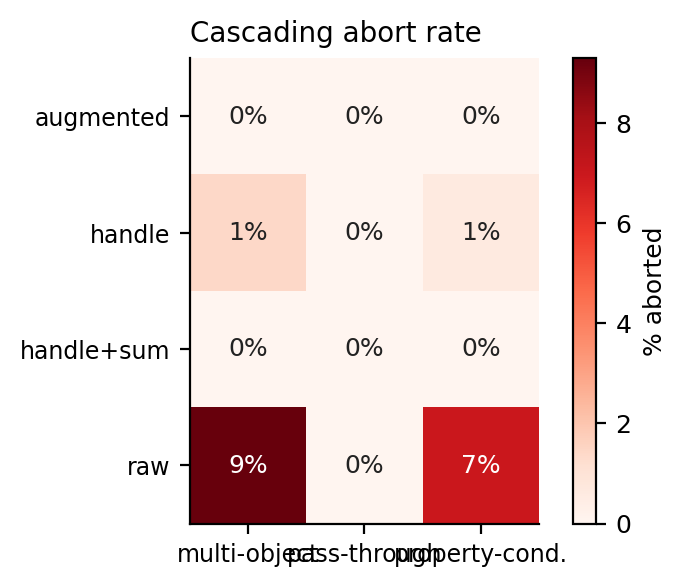

fig1_table4.png


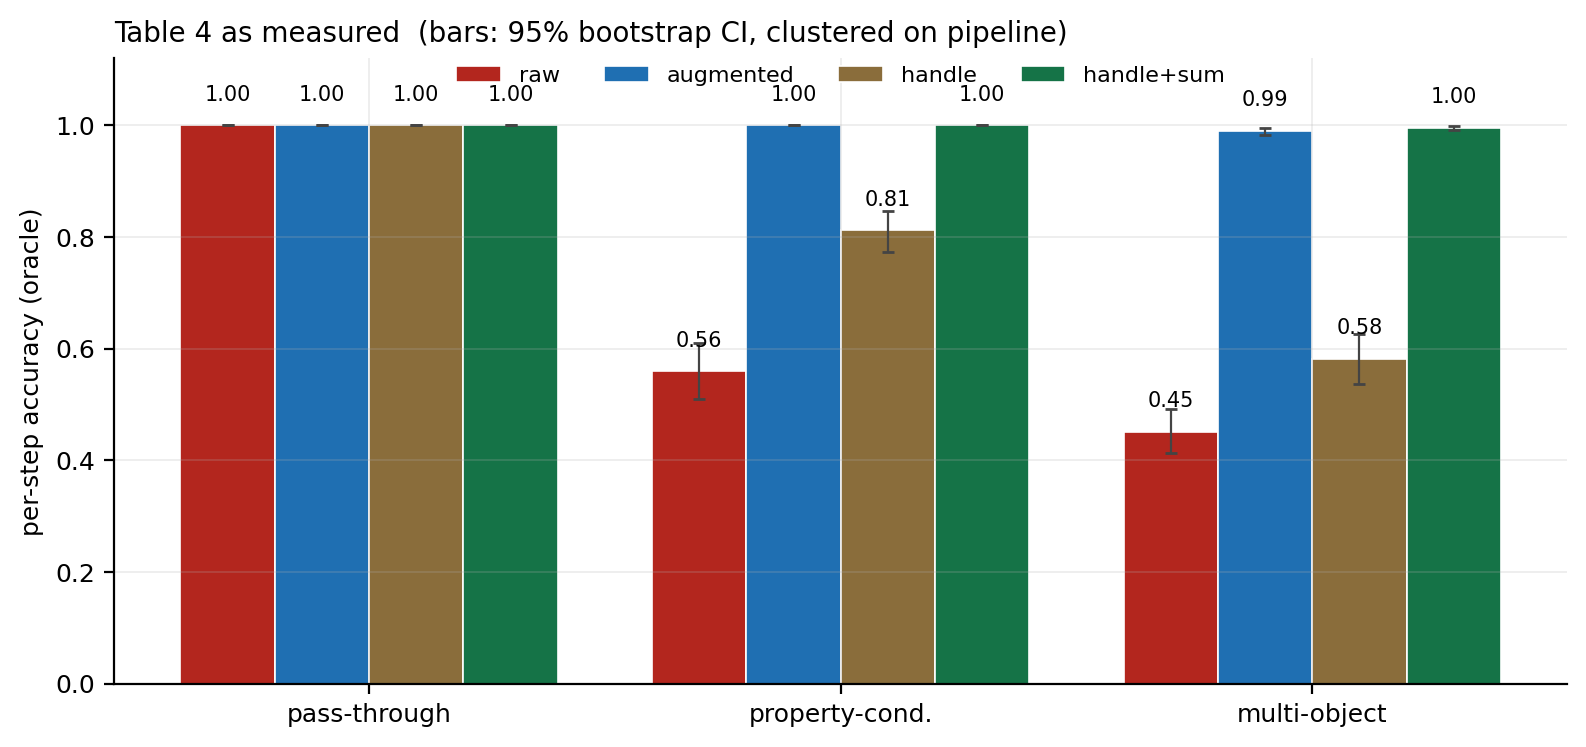

fig2_ordering.png


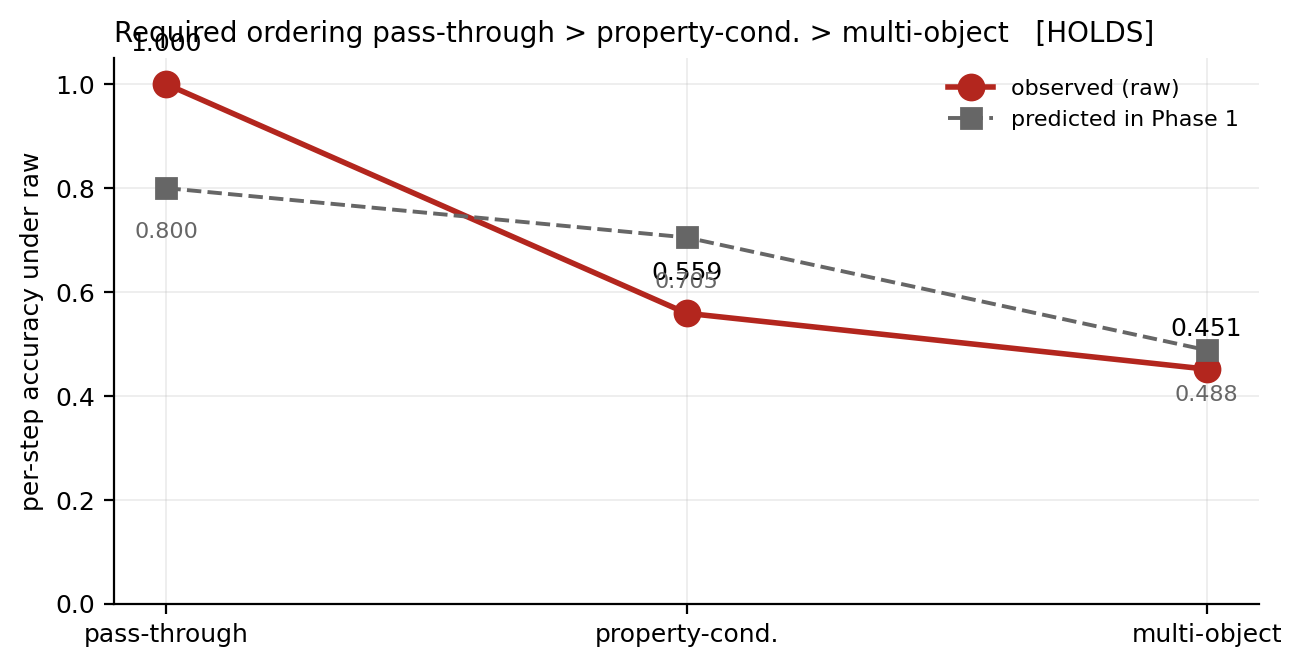

fig3_gains.png


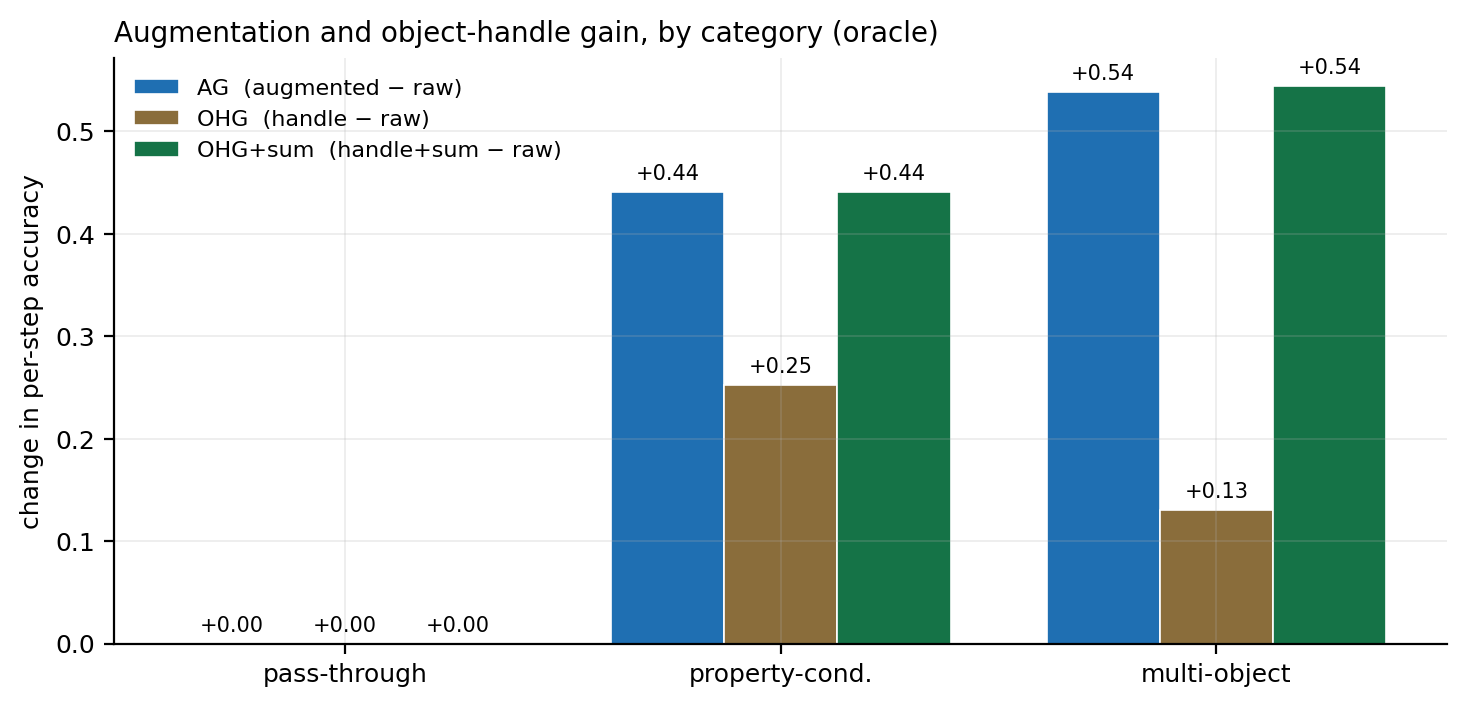

fig4_gate_gradient.png


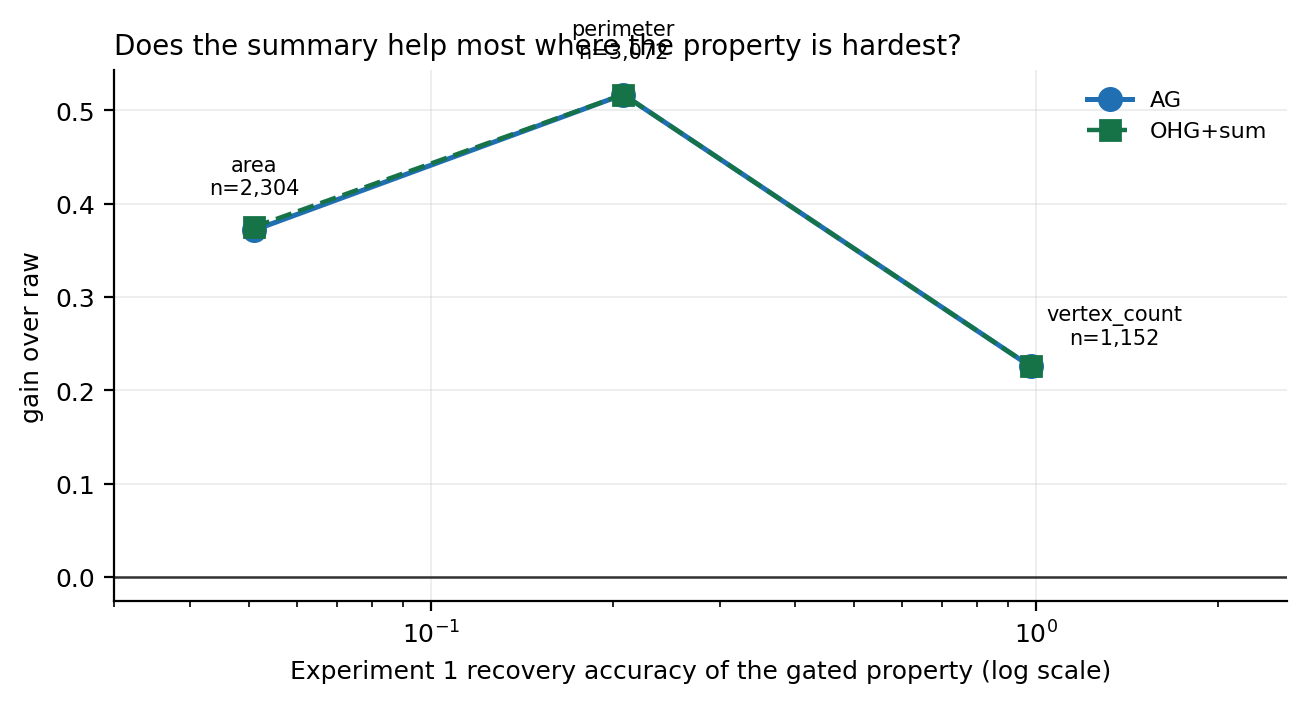

fig5_survival.png


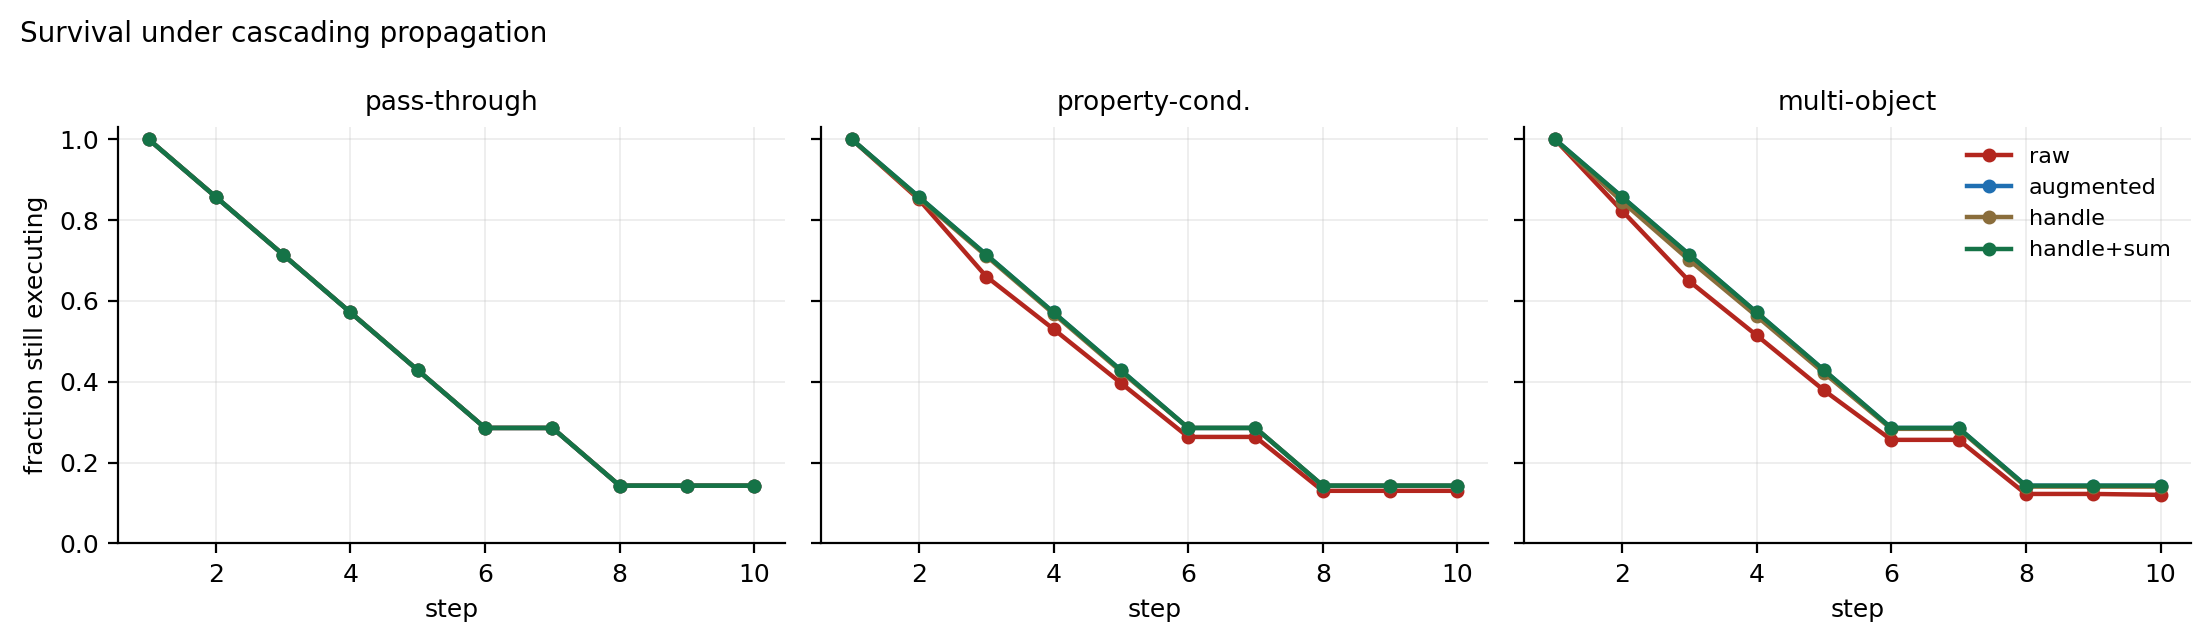

fig6_perstep_multi_object.png


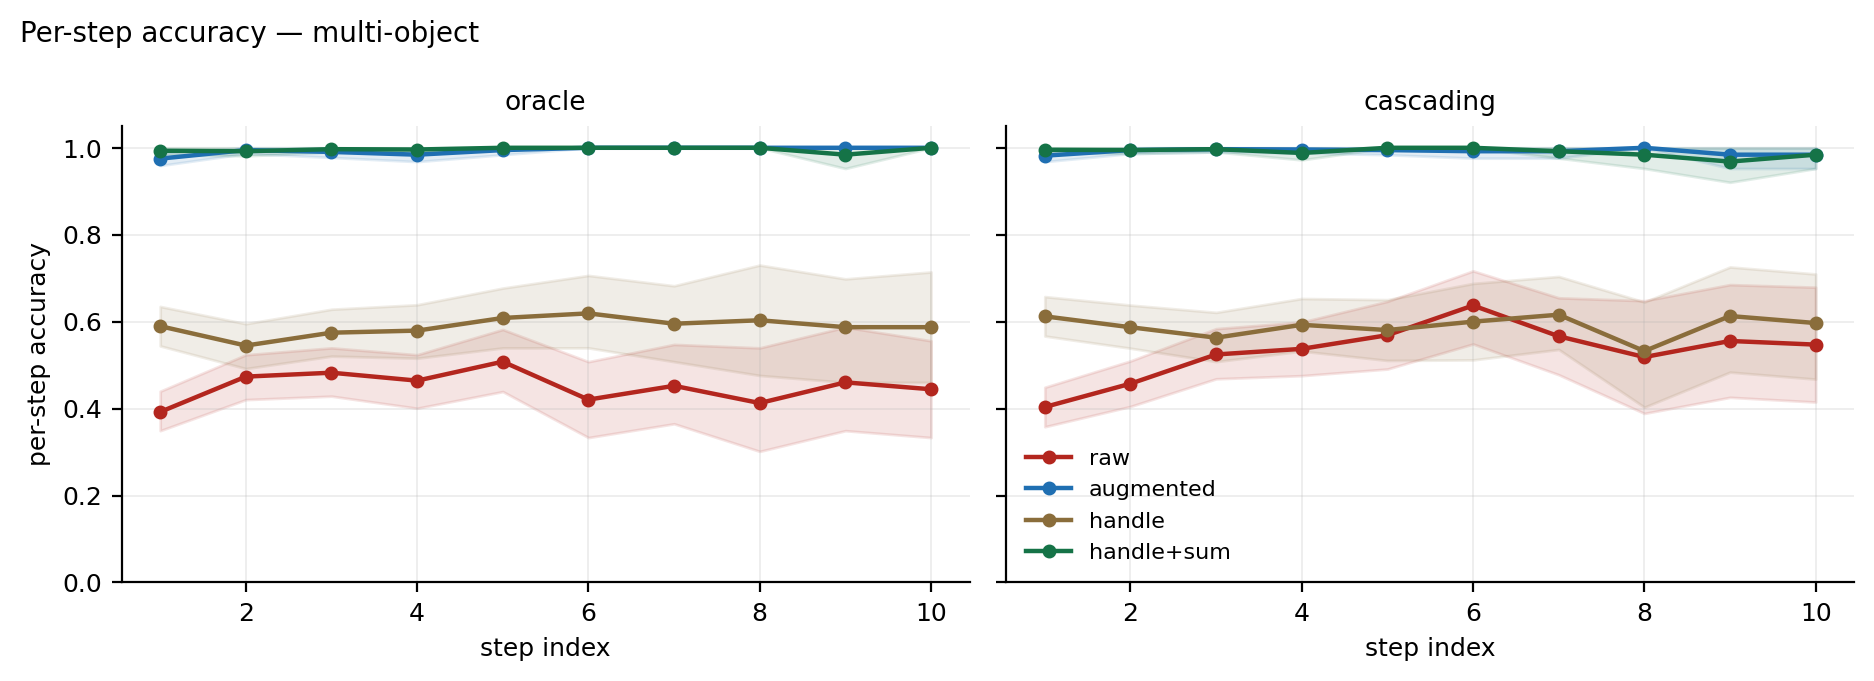

fig6_perstep_pass_through.png


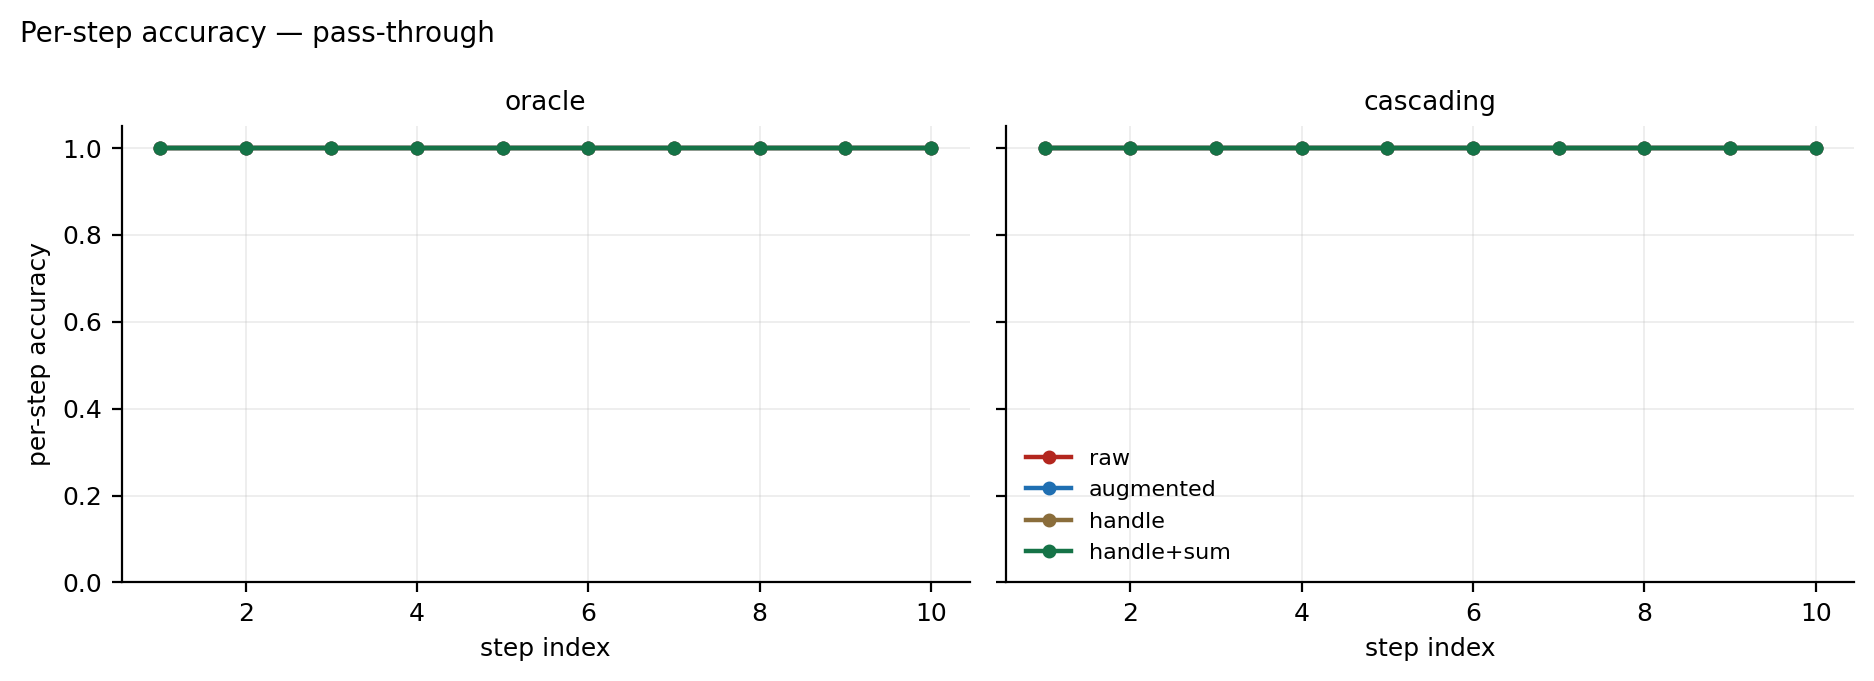

fig6_perstep_property_conditioned.png


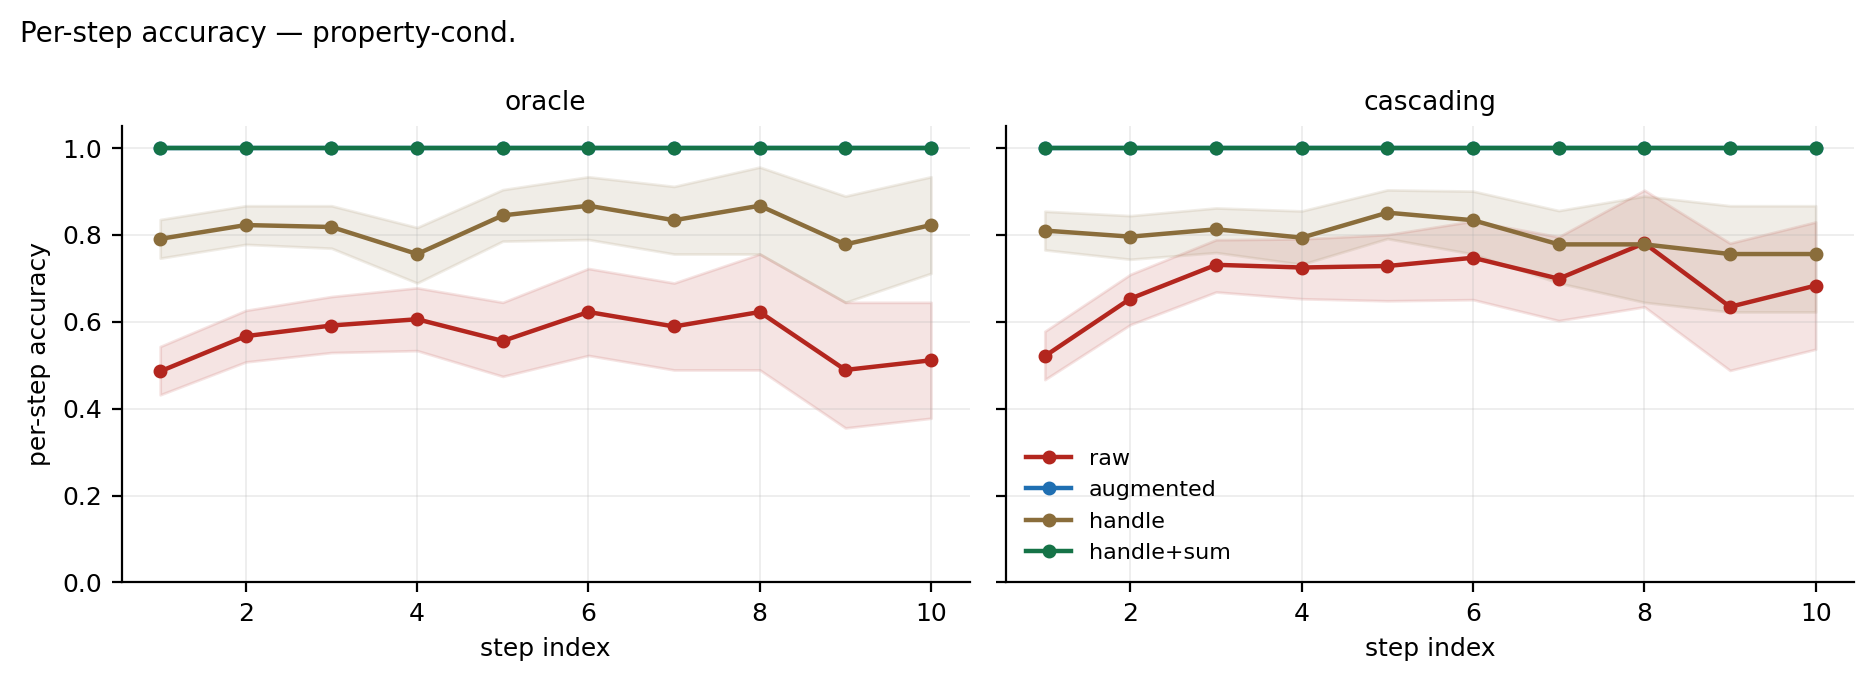

fig7_aux.png


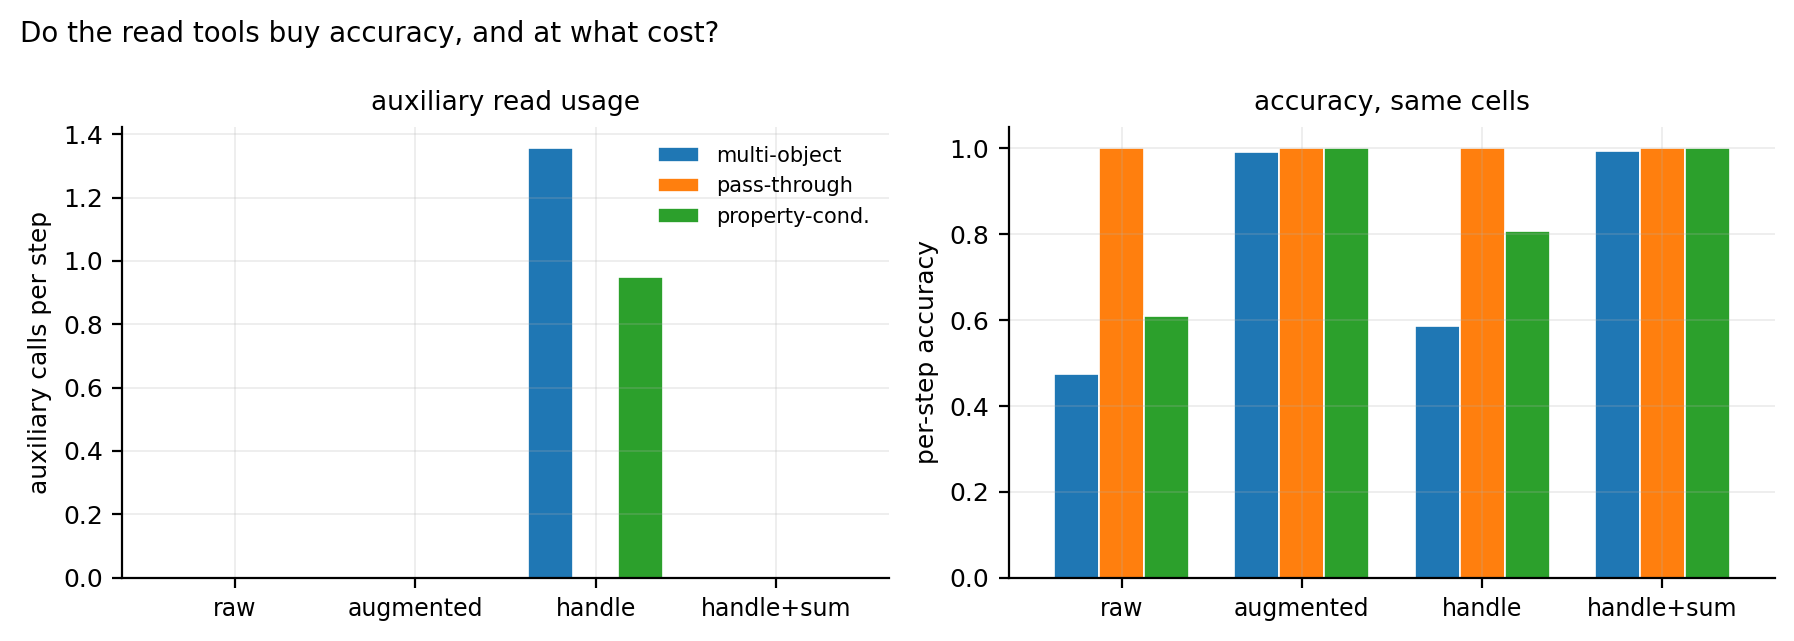

fig8_chance.png


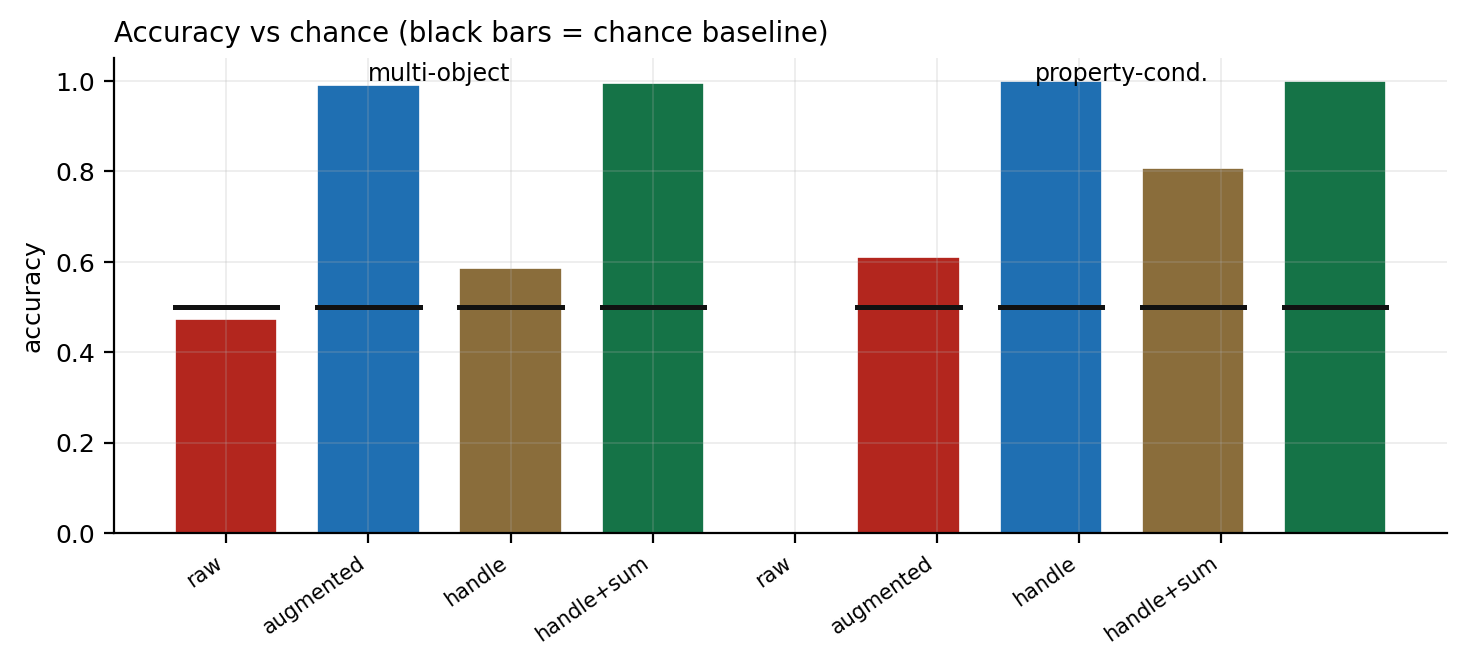

fig9_tokens.png


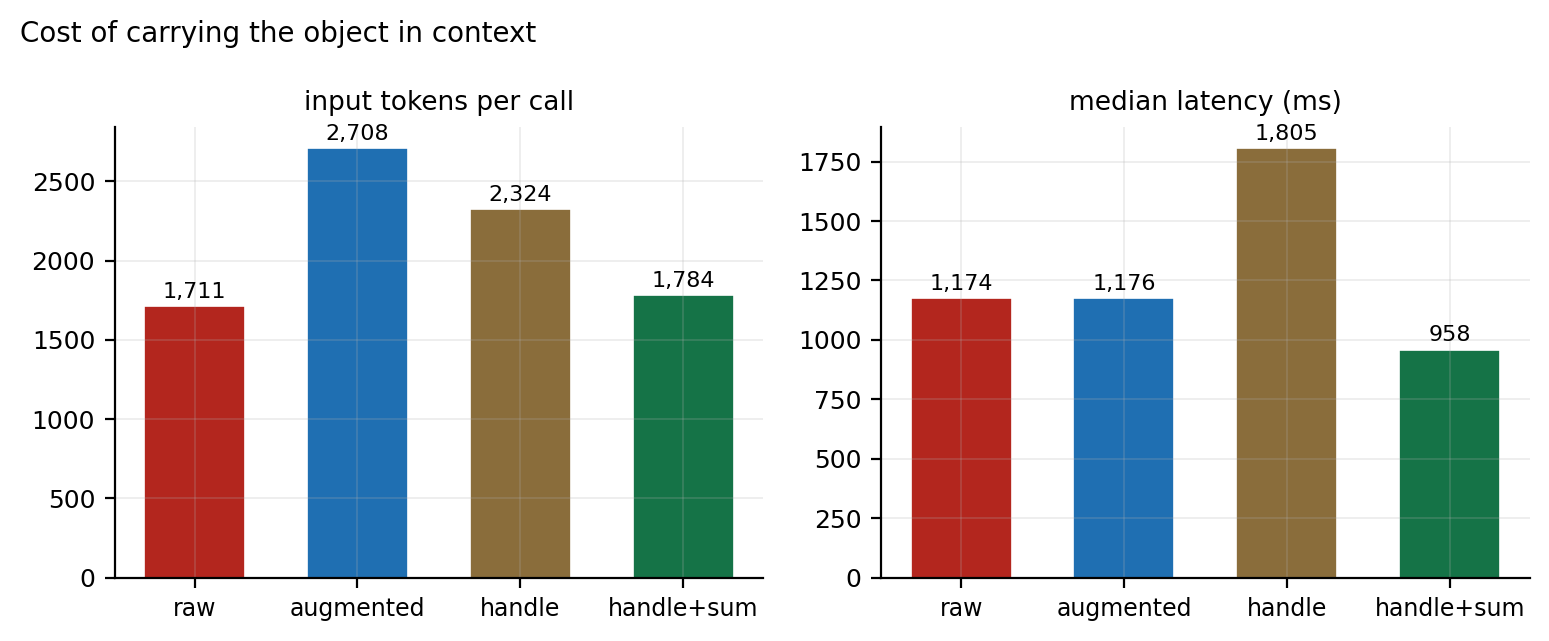

In [17]:
from IPython.display import Image, display
import glob
for p in sorted(glob.glob("fig*.png")):
    print(p); display(Image(p))

# CELL 17B — Result comparison

FIGURE A — grouped by condition; each group must be non-increasing
  condition                 pass-through    property-cond.      multi-object   verdict
  raw                              1.000             0.559             0.451   non-increasing
  augmented                        1.000             1.000             0.990   non-increasing
  handle only                      1.000             0.812             0.582   non-increasing
  handle + summary                 1.000             1.000             0.996   non-increasing

  all four conditions non-increasing: YES

FIGURE B — grouped by pipeline type, over Table 4's three columns
  pipeline type                          raw         handle only    handle + summary   shape
  pass-through                 1.000 High          1.000 High          1.000 High      mixed
  property-cond.               0.559 Low-Medium       0.812 Medium        1.000 High      rises throughout
  multi-object                 0.451 Low           0.582 Low-Medium

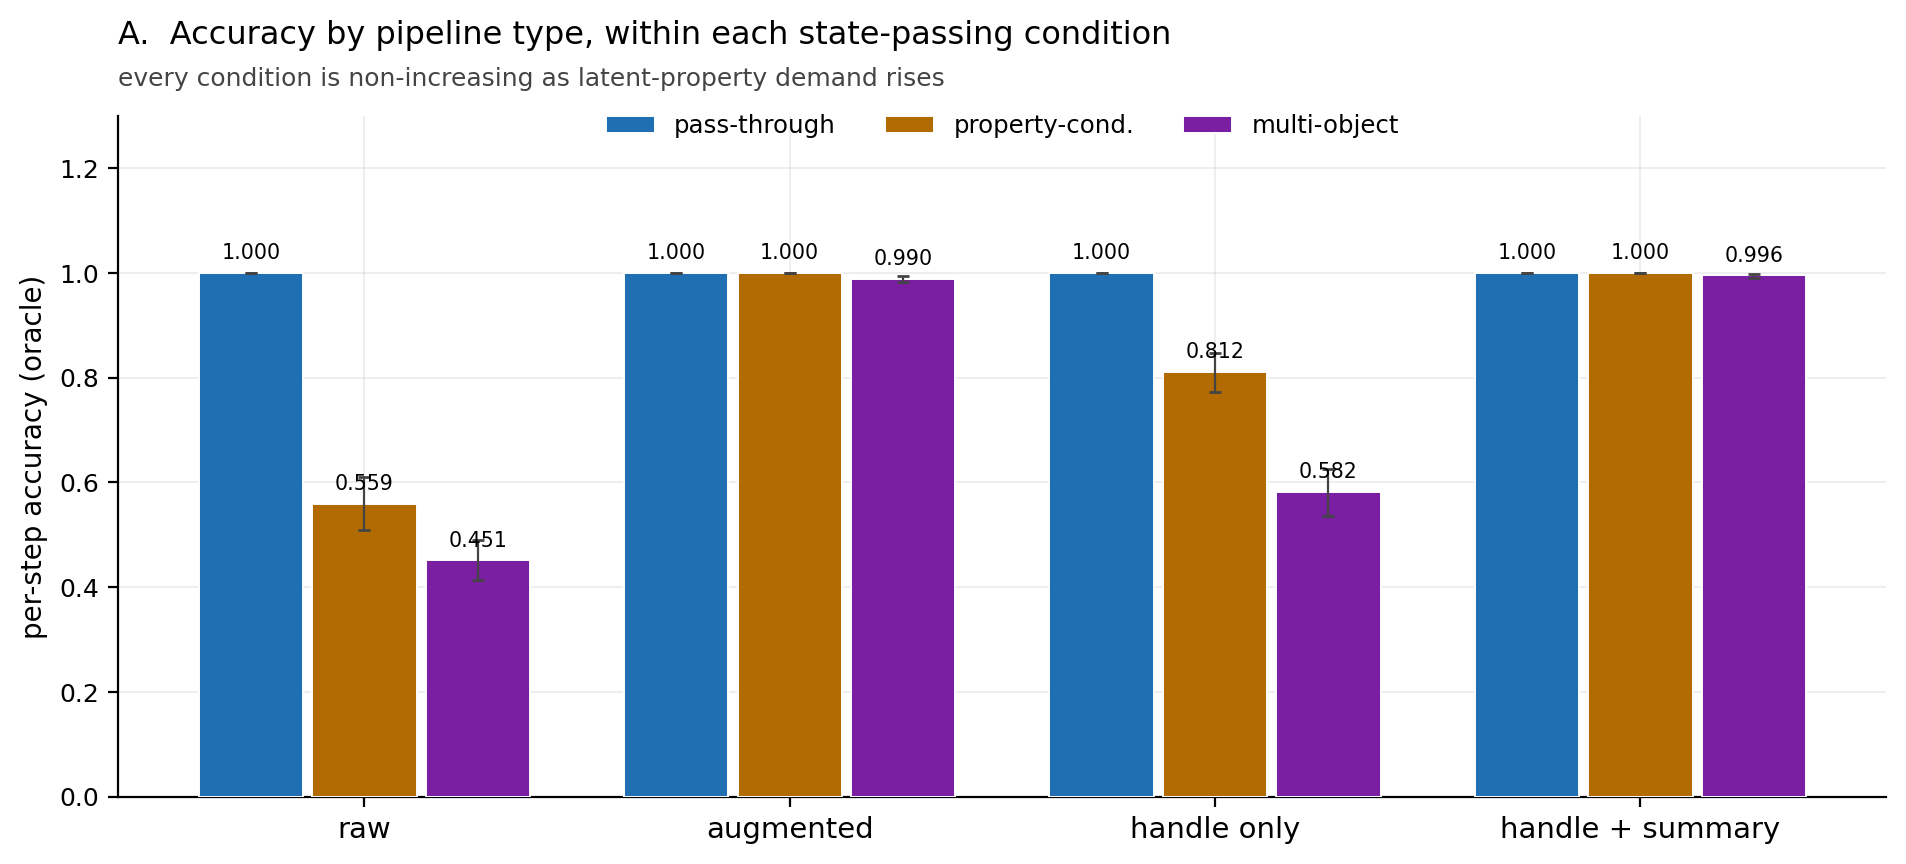

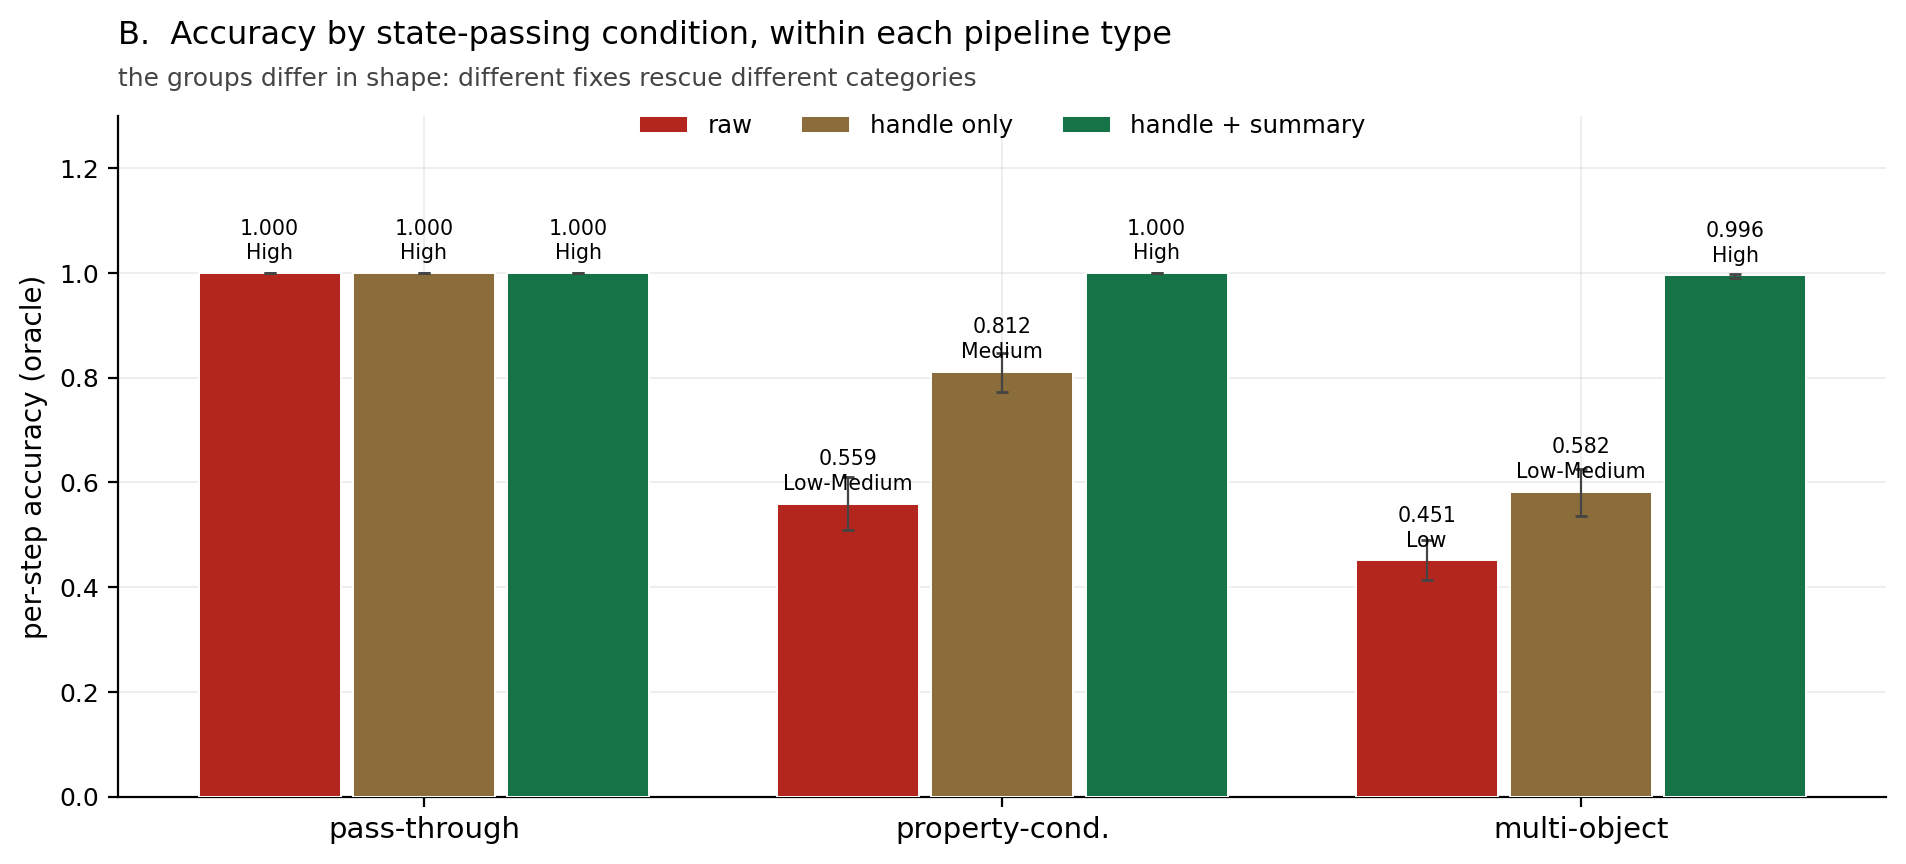


wrote fig0a_by_condition.png and fig0b_by_pipeline.png


In [18]:
# ================== CELL 17B — Table 4, two grouped bar charts ==================
# The same nine numbers, grouped two ways.
#
#   FIGURE A   grouped by state-passing condition. Within each group the three
#              pipeline types must be NON-INCREASING: every category demands more
#              latent-property reconstruction than the one before it.
#
#   FIGURE B   grouped by pipeline type, over Table 4's own three columns. This
#              is where the two-factor pattern shows: the groups do not have the
#              same shape, because different categories are rescued by different
#              fixes.

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

CAT_ORDER = ["pass_through", "property_conditioned", "multi_object"]
CON_ORDER = ["raw", "augmented", "handle", "handle_sum"]
T4_COLS   = ["raw", "handle", "handle_sum"]          # Table 4's own columns
CC   = {"raw": "#B3261E", "augmented": "#1F6FB2",
        "handle": "#8A6D3B", "handle_sum": "#157347"}
CATC = {"pass_through": "#1F6FB2", "property_conditioned": "#B26B00",
        "multi_object": "#7A1FA2"}
LBL   = {"raw": "raw", "augmented": "augmented",
         "handle": "handle only", "handle_sum": "handle + summary"}
SHORT = {"raw": "raw", "augmented": "augmented",
         "handle": "handle only", "handle_sum": "handle + summary"}

BANDS = [(0.00, 0.35, "Very low"), (0.35, 0.55, "Low"),
         (0.55, 0.70, "Low-Medium"), (0.70, 0.85, "Medium"), (0.85, 1.01, "High")]
def band(v):
    for lo, hi, name in BANDS:
        if lo <= v < hi: return name
    return "High"

obs  = {r["category"]: r for r in t4.to_dict("records")}
cats = [c for c in CAT_ORDER if c in obs]


def draw(groups, series, value, colour, glabel, slabel, title, subtitle,
         fname, annot=None):
    """One grouped bar chart. `groups` are the x positions, `series` the bars
    inside each group."""
    fig, ax = plt.subplots(figsize=(9.6, 4.4))
    x = np.arange(len(groups))
    w = 0.8 / len(series)
    for i, s in enumerate(series):
        v = [value(g, s) for g in groups]
        err = np.vstack([[value(g, s) - obs[g if g in obs else s][(s if g in obs else g) + "_lo"]
                          for g in groups],
                         [obs[g if g in obs else s][(s if g in obs else g) + "_hi"] - value(g, s)
                          for g in groups]])
        off = (i - (len(series) - 1) / 2) * w
        b = ax.bar(x + off, v, w * 0.92, label=slabel(s), color=colour(s),
                   edgecolor="white", lw=0.7, yerr=err, capsize=2,
                   error_kw=dict(lw=0.8, ecolor="#444"), zorder=3)
        for rect, val, g in zip(b, v, groups):
            txt = f"{val:.3f}" if annot is None else f"{val:.3f}\n{annot(g, s)}"
            ax.annotate(txt, (rect.get_x() + rect.get_width() / 2, val),
                        textcoords="offset points", xytext=(0, 5), ha="center",
                        fontsize=7.4, linespacing=1.3, zorder=4)
    ax.set_xticks(x)
    ax.set_xticklabels([glabel(g) for g in groups], fontsize=10.5)
    ax.set_ylim(0, 1.30)
    ax.set_ylabel("per-step accuracy (oracle)", fontsize=10)
    ax.set_title(title, loc="left", fontsize=11.5, pad=26)
    ax.text(0, 1.045, subtitle, transform=ax.transAxes, fontsize=9, color="#444")
    ax.legend(frameon=False, fontsize=8.8, ncol=len(series),
              loc="upper center", bbox_to_anchor=(0.5, 1.035))
    ax.grid(axis="y", alpha=0.25, lw=0.6, zorder=0)
    fig.tight_layout()
    fig.savefig(fname, dpi=200, bbox_inches="tight")
    plt.close(fig)
    return fname


# ----------------------------------------------------------------- FIGURE A
print("=" * 86)
print("FIGURE A — grouped by condition; each group must be non-increasing")
print("=" * 86)
print(f"  {'condition':20s}" + "".join(f"{CATLABEL[c]:>18s}" for c in cats) + "   verdict")
all_ok = True
for c in CON_ORDER:
    v = [obs[cat][c] for cat in cats]
    ok = all(v[i] >= v[i + 1] for i in range(len(v) - 1)); all_ok &= ok
    print(f"  {LBL[c]:20s}" + "".join(f"{x:18.3f}" for x in v)
          + f"   {'non-increasing' if ok else 'VIOLATION'}")
print(f"\n  all four conditions non-increasing: {'YES' if all_ok else 'NO'}")

fa = draw(groups=CON_ORDER, series=cats,
          value=lambda g, s: obs[s][g],
          colour=lambda s: CATC[s], glabel=lambda g: SHORT[g],
          slabel=lambda s: CATLABEL[s],
          title="A.  Accuracy by pipeline type, within each state-passing condition",
          subtitle="every condition is non-increasing as latent-property demand rises",
          fname="fig0a_by_condition.png")

# ----------------------------------------------------------------- FIGURE B
print("\n" + "=" * 86)
print("FIGURE B — grouped by pipeline type, over Table 4's three columns")
print("=" * 86)
print(f"  {'pipeline type':22s}" + "".join(f"{LBL[c]:>20s}" for c in T4_COLS) + "   shape")
for cat in cats:
    v = [obs[cat][c] for c in T4_COLS]
    shape = ("dips then recovers" if v[1] < v[0] < v[2]
             else "rises then flat" if v[0] < v[1] and abs(v[2] - v[1]) < 0.05
             else "rises throughout" if v[0] < v[1] < v[2] else "mixed")
    print(f"  {CATLABEL[cat]:22s}"
          + "".join(f"{x:12.3f} {band(x):<7s}" for x in v) + f"   {shape}")

fb = draw(groups=cats, series=T4_COLS,
          value=lambda g, s: obs[g][s],
          colour=lambda s: CC[s], glabel=lambda g: CATLABEL[g],
          slabel=lambda s: LBL[s],
          title="B.  Accuracy by state-passing condition, within each pipeline type",
          subtitle="the groups differ in shape: different fixes rescue different categories",
          fname="fig0b_by_pipeline.png",
          annot=lambda g, s: band(obs[g][s]))

# Cell 12 sets the Agg backend, so plt.show() is a no-op. Read the files back,
# which also guarantees you see exactly what gets downloaded.
for f in (fa, fb):
    display(Image(f))
print(f"\nwrote {fa} and {fb}")

## [CELL 18] Write metrics.json and download

In [19]:
out = {
    "coverage_problems": problems,
    "table4": t4.to_dict("records"),
    "ordering_holds": bool(order_ok),
    "predicted_raw": PREDICTED_RAW,
    "gains_per_category": g.to_dict("records"),
    "gains_by_gate": gg.to_dict("records"),
    "per_step_by_index": {c: per_step_by_index(steps, c).to_dict("records")
                          for c in CATEGORIES},
    "survival": sv.to_dict("records"),
    "end_to_end": e2e.to_dict("records"),
    "eaf": E.to_dict("records"),
    "aux_usage": ax_df.to_dict("records"),
    "chance_baseline": cb.to_dict("records"),
    "abort_rate": rate.to_dict(),
    "abort_causes": cause.to_dict() if len(cause) else {},
    "failure_attribution": fa.to_dict() if len(fa) else {},
    "token_cost": tc.to_dict("records"),
}
json.dump(out, open("metrics.json", "w"), indent=1, default=str)
print("wrote metrics.json")
if problems:
    print("\nREMINDER: coverage problems were detected. These metrics describe the")
    print("run that happened, not the population.")
try:
    import glob
    from google.colab import files
    files.download("metrics.json")
    for p in sorted(glob.glob("fig*.png")): files.download(p)
except Exception as e:
    print("not in Colab; outputs are on disk:", e)

AttributeError: 'str' object has no attribute 'to_dict'